In [3]:
!pip install scanpy pandas matplotlib seaborn python-igraph leidenalg

import scanpy as sc

# 1. Load the 3k PBMC dataset from 10x Genomics
adata = sc.datasets.pbmc3k()

# 2. Make gene names unique (crucial for mapping later)
adata.var_names_make_unique()

# 3. View the 'AnnData' object summary
adata

  Using cached pandas-3.0.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached numpy-2.4.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 4.9 MB/s  0:00:00a 0:00:01m eta 0:00:01
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 6.0 MB/s  0:00:006.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━

Matplotlib is building the font cache; this may take a moment.
/Users/adamdymke/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████████████████████████████████| 5.58M/5.58M [00:37<00:00, 158kB/s]


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

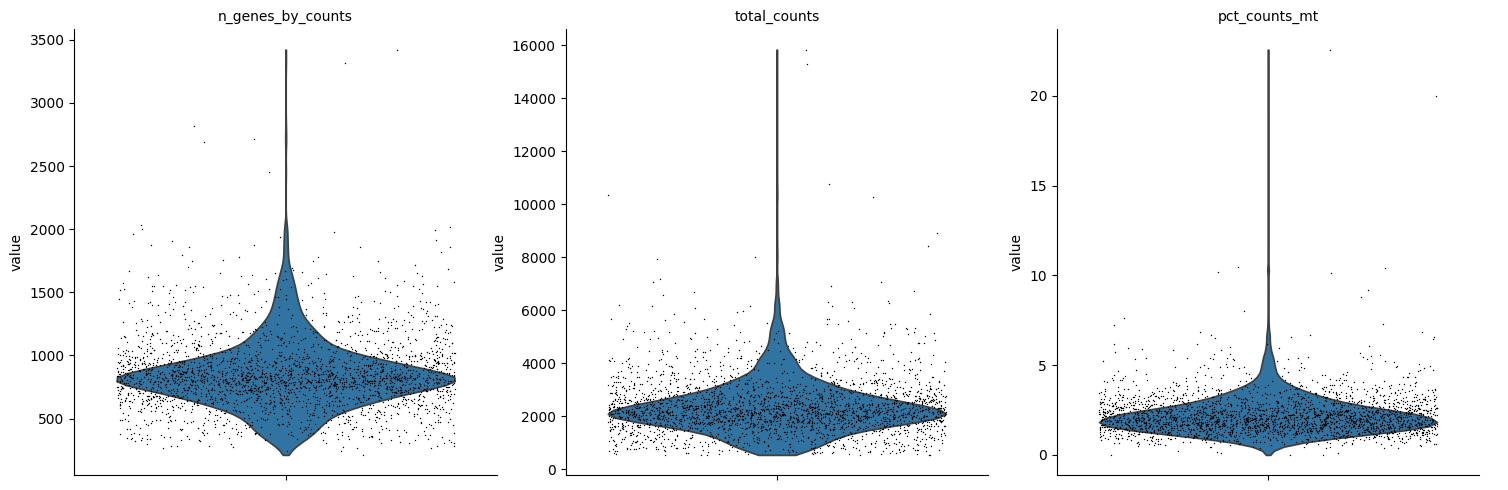

In [7]:
# Identify mitochondrial genes (they start with 'MT-')
adata.var['mt'] = adata.var_names.str.startswith('MT-') 

# Calculate QC metrics (number of genes, total counts, % mitochondrial)
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Visualize the noise with Violin Plots
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

In [8]:
# 1. Filter out cells with fewer than 200 genes (likely empty droplets)
sc.pp.filter_cells(adata, min_genes=200)

# 2. Filter out genes found in fewer than 3 cells (not statistically significant)
sc.pp.filter_genes(adata, min_cells=3)

# 3. Filter out cells with more than 5% mitochondrial counts (dying cells)
# We use the 'pct_counts_mt' column we calculated in the last step
adata = adata[adata.obs.pct_counts_mt < 5, :]

# 4. Filter out cells with more than 2500 genes (potential doublets)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]

# Show how many cells are left
print(f"Cells remaining after filtering: {adata.n_obs}")

Cells remaining after filtering: 2638


In [9]:
# Scale every cell to have a total count of 10,000
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform the data (this makes the distribution more 'normal')
sc.pp.log1p(adata)

# Store the 'raw' data so we can refer back to it later for plotting
adata.raw = adata

/var/folders/jq/xtlqlq7x5dg1t1m93vrd8lwm0000gn/T/ipykernel_2959/471225889.py:2: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


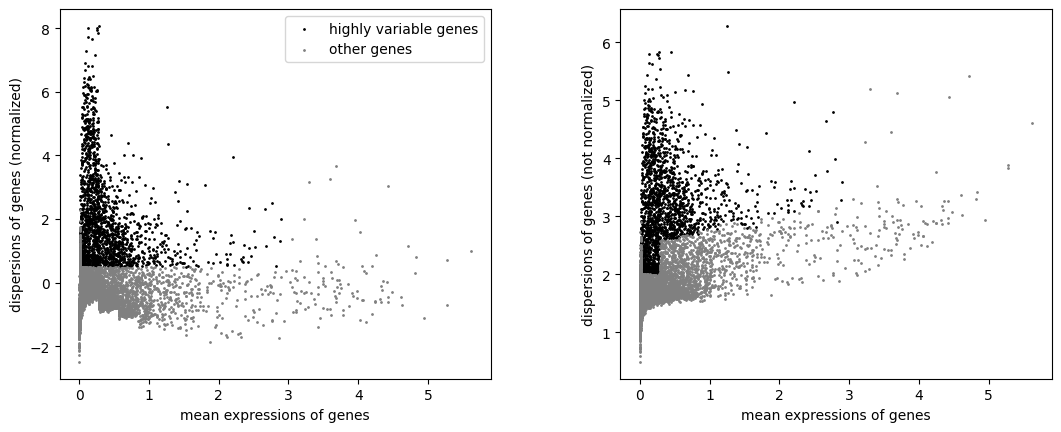

In [10]:
# Identify genes that vary the most across the dataset
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Visualize the variable genes
sc.pl.highly_variable_genes(adata)

# Actually filter the data to only keep these genes for the heavy math steps
adata = adata[:, adata.var.highly_variable].copy()

/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


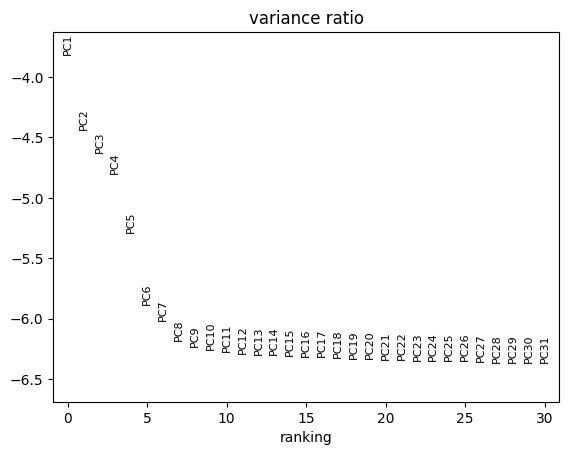

In [11]:
# 1. Scale the data so that each gene has zero mean and unit variance
# This is crucial for PCA because it prevents high-count genes from dominating
sc.pp.scale(adata, max_value=10)

# 2. Run PCA (Principal Component Analysis)
sc.tl.pca(adata, svd_solver='arpack')

# 3. Create an 'Elbow Plot' (Ranking of PCs)
# We look for where the curve 'elbows' or flattens out.
sc.pl.pca_variance_ratio(adata, log=True)

/var/folders/jq/xtlqlq7x5dg1t1m93vrd8lwm0000gn/T/ipykernel_2959/4170236037.py:9: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


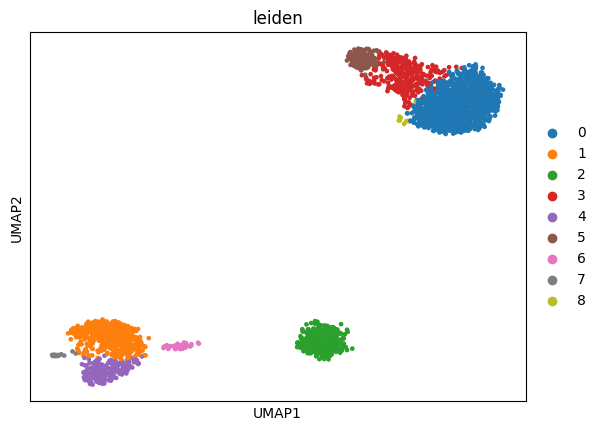

In [12]:
# 1. Compute the neighborhood graph 
# (using 10 neighbors and the first 40 PCs)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# 2. Run UMAP (Manifold Learning)
sc.tl.umap(adata)

# 3. Run Leiden Clustering (The unsupervised grouping)
sc.tl.leiden(adata)

# 4. Plot the results!
sc.pl.umap(adata, color=['leiden'])

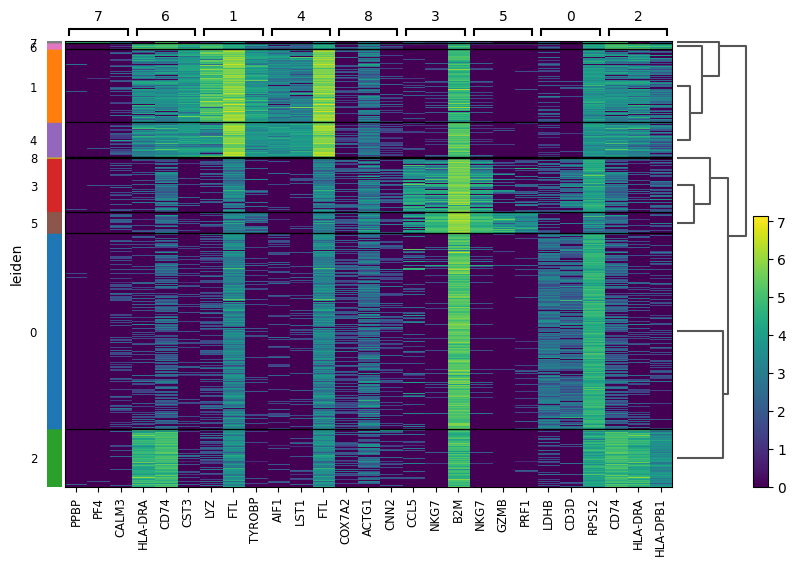

In [13]:
# Find the genes that define each cluster compared to all other clusters
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')

# Visualize the top 3 marker genes for each cluster in a heatmap
sc.pl.rank_genes_groups_heatmap(adata, n_genes=3, key='rank_genes_groups', groupby='leiden', show_gene_labels=True)